# Import Libraries

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading Dataset

In [ ]:
bank_data=pd.read_excel('/content/drive/MyDrive/Final Data Analysis.xlsx')

#Defining Target Column

In [ ]:
X = bank_data.drop("y", axis=1)
y = bank_data["y"]

#Splitting Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# MODEL 1 — Logistic Regression

In [ ]:

categorical_cols_X = X_train.select_dtypes(include='object').columns
X_train_processed = pd.get_dummies(X_train, columns=categorical_cols_X)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols_X)
X_train_processed, X_test_processed = X_train_processed.align(X_test_processed, join='outer', axis=1, fill_value=0)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train_encoded)

y_pred_lr = lr.predict(X_test_scaled)

# MODEL 2 — Random Forest

In [ ]:
categorical_cols_X_rf = X_train.select_dtypes(include='object').columns
X_train_processed_rf = pd.get_dummies(X_train, columns=categorical_cols_X_rf)
X_test_processed_rf = pd.get_dummies(X_test, columns=categorical_cols_X_rf)

X_train_processed_rf, X_test_processed_rf = X_train_processed_rf.align(X_test_processed_rf, join='outer', axis=1, fill_value=0)

le_rf = LabelEncoder()
y_train_encoded_rf = le_rf.fit_transform(y_train)
y_test_encoded_rf = le_rf.transform(y_test)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_processed_rf, y_train_encoded_rf)

y_pred_rf = rf.predict(X_test_processed_rf)

# Evaluating Models

In [ ]:
def evaluate(name, y_test, y_pred):
    print(f"\n {name}")
    print()
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print()
    print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
evaluate("Logistic Regression", y_test_encoded, y_pred_lr)


 Logistic Regression

Accuracy: 0.7440712262242007

Confusion Matrix:
 [[8377 2638]
 [ 524  816]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.76      0.84     11015
           1       0.24      0.61      0.34      1340

    accuracy                           0.74     12355
   macro avg       0.59      0.68      0.59     12355
weighted avg       0.86      0.74      0.79     12355



In [ ]:
evaluate("Random Forest", y_test_encoded_rf, y_pred_rf)


 Random Forest

Accuracy: 0.8986645082962363

Confusion Matrix:
 [[10913   102]
 [ 1150   190]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.95     11015
           1       0.65      0.14      0.23      1340

    accuracy                           0.90     12355
   macro avg       0.78      0.57      0.59     12355
weighted avg       0.88      0.90      0.87     12355



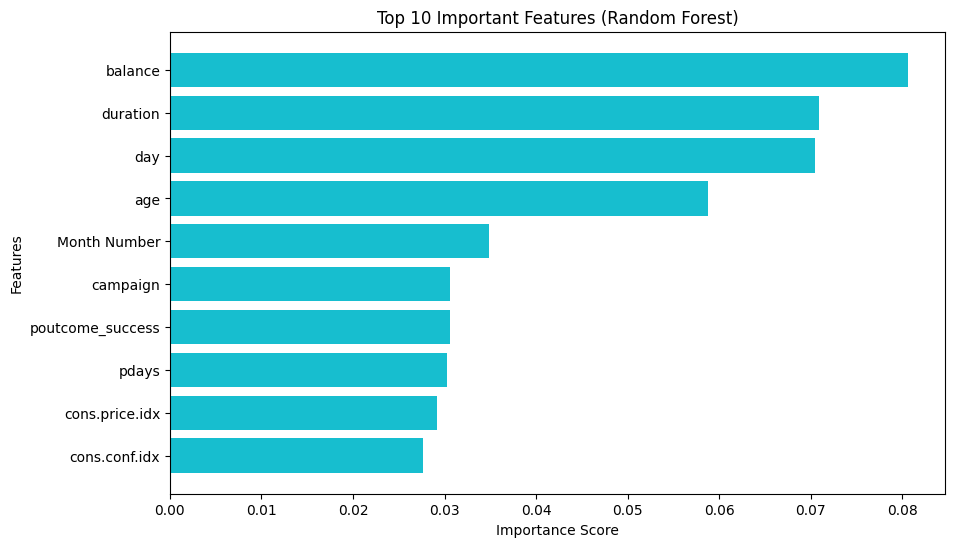

In [ ]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_processed_rf.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_features['Feature'], top_features['Importance'],color='tab:cyan')
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Selecting Features

In [ ]:
features = [
    'age',
    'balance',
    'campaign',
    'pdays',
    'previous',
    'housing',
    'loan',
    'contact',
    'poutcome',
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx'
]

X = bank_data[features]

# Scaling Data

In [ ]:
categorical_cols_X_clustering = X.select_dtypes(include='object').columns

X_processed_clustering = pd.get_dummies(X, columns=categorical_cols_X_clustering, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed_clustering)

# Elbow Method

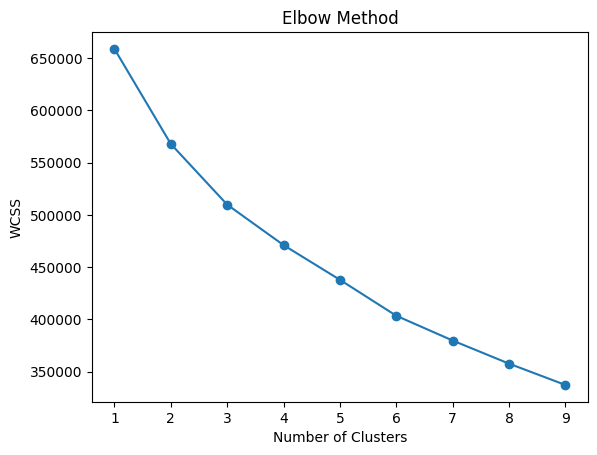

In [ ]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# K-Mean / Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
bank_data['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
cluster_summary = bank_data.groupby('Cluster')[features].mean(numeric_only=True)
print("\nCluster Characteristics:\n", cluster_summary)

print()

cluster_size = bank_data['Cluster'].value_counts()
print("\nCluster Size:\n", cluster_size)


Cluster Characteristics:
                age      balance  campaign       pdays  previous  emp.var.rate  \
Cluster                                                                         
0        40.105037  1236.880783  3.028026   -0.947147  0.002244      1.203509   
1        39.562328  1442.598376  2.065355  231.474408  0.175289     -0.062424   
2        40.160910  1263.105783  2.782113   -0.501388  0.446723     -1.647448   

         cons.price.idx  cons.conf.idx  
Cluster                                 
0             93.952933     -39.220759  
1             93.510171     -40.863539  
2             93.003390     -42.372699  


Cluster Size:
 Cluster
0    20945
2    12970
1     7268
Name: count, dtype: int64
